# 01 - Analise Exploratoria (EDA)

Dataset: [Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit/data) (Kaggle).

Objetivo desta etapa: entender a qualidade e a distribuicao dos dados antes de
partir para engenharia de atributos e modelagem.

## Setup

In [2]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_ingestion import load_raw_data, clean_data

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## Carregamento dos dados brutos

In [4]:
df_raw = load_raw_data("../data/raw/cs-training.csv")
df = clean_data(df_raw)

print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
df.head()


Linhas: 149,999 | Colunas: 11


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2.0,0.802982,9120.0,13,0.0,6,0.0,2.0
1,0,0.957151,40,0.0,0.121876,2600.0,4,0.0,0,0.0,1.0
2,0,0.658180,38,1.0,0.085113,3042.0,2,1.0,0,0.0,0.0
3,0,0.233810,30,0.0,0.036050,3300.0,5,0.0,0,0.0,0.0
4,0,0.907239,49,1.0,0.024926,63588.0,7,0.0,1,0.0,0.0


## Estatisticas descritivas e tipos de dado

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 149999 entries, 0 to 149998
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149999 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  149999 non-null  float64
 2   age                                   149999 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149730 non-null  float64
 4   DebtRatio                             149999 non-null  float64
 5   MonthlyIncome                         120268 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       149999 non-null  int64  
 7   NumberOfTimes90DaysLate               149730 non-null  float64
 8   NumberRealEstateLoansOrLines          149999 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  149730 non-null  float64
 10  NumberOfDependents                    146075 non-null  float64
dtypes: float64(

In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,149999.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,149999.0,6.048472,249.756203,0.0,0.029867,0.154176,0.559044,50708.0
age,149999.0,52.295555,14.771298,21.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,149730.0,0.245789,0.697779,0.0,0.000000,0.000000,0.000000,13.0
DebtRatio,149999.0,353.007426,2037.825113,0.0,0.175074,0.366503,0.868257,329664.0
MonthlyIncome,120268.0,6670.226810,14384.733888,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,149999.0,8.452776,5.145964,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,149730.0,0.090456,0.485529,0.0,0.000000,0.000000,0.000000,17.0
NumberRealEstateLoansOrLines,149999.0,1.018233,1.129772,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,149730.0,0.064823,0.330074,0.0,0.000000,0.000000,0.000000,11.0


## Analise de valores ausentes

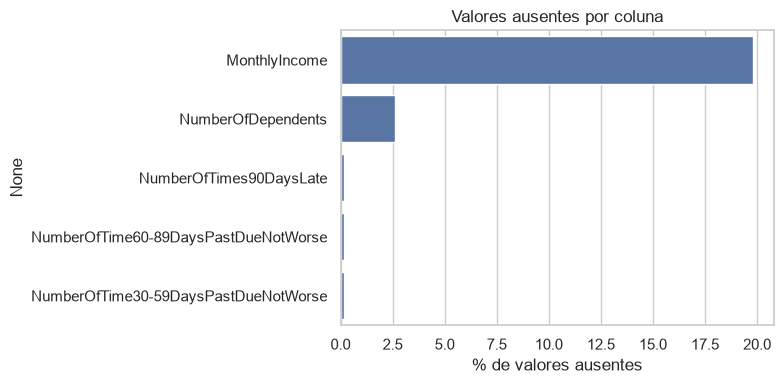

MonthlyIncome                           19.820799
NumberOfDependents                       2.616017
NumberOfTimes90DaysLate                  0.179335
NumberOfTime60-89DaysPastDueNotWorse     0.179335
NumberOfTime30-59DaysPastDueNotWorse     0.179335
dtype: float64

In [7]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=missing.values, y=missing.index, ax=ax, color="#4C72B0")
ax.set_xlabel("% de valores ausentes")
ax.set_title("Valores ausentes por coluna")
plt.tight_layout()
plt.show()

missing


**Nota:** `MonthlyIncome` e `NumberOfDependents` sao os unicos campos com valores ausentes relevantes. A estrategia de imputacao sera definida na etapa de engenharia de atributos (`02_feature_engineering.ipynb`).

## Distribuicao da variavel alvo (SeriousDlqin2yrs)

C:\Users\Fernando\AppData\Local\Temp\ipykernel_6316\1866187575.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax,
C:\Users\Fernando\AppData\Local\Temp\ipykernel_6316\1866187575.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Adimplente (0)", "Inadimplente (1)"])


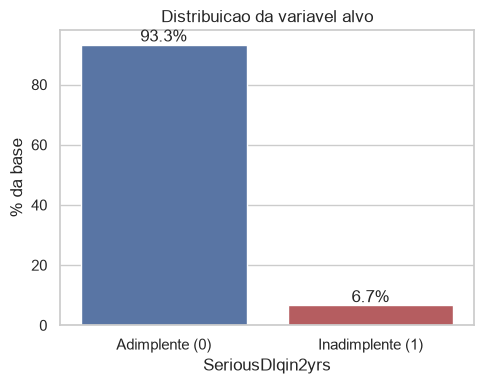

In [8]:
target_counts = df["SeriousDlqin2yrs"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax,
            palette=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Adimplente (0)", "Inadimplente (1)"])
ax.set_ylabel("% da base")
ax.set_title("Distribuicao da variavel alvo")
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()


**Nota:** classe fortemente desbalanceada (minoria = inadimplentes), padrao em problemas de risco de credito. Mesma familia de tecnicas (SMOTE) usada no projeto de Deteccao de Fraudes sera reaproveitada aqui.

## Distribuicao das variaveis numericas

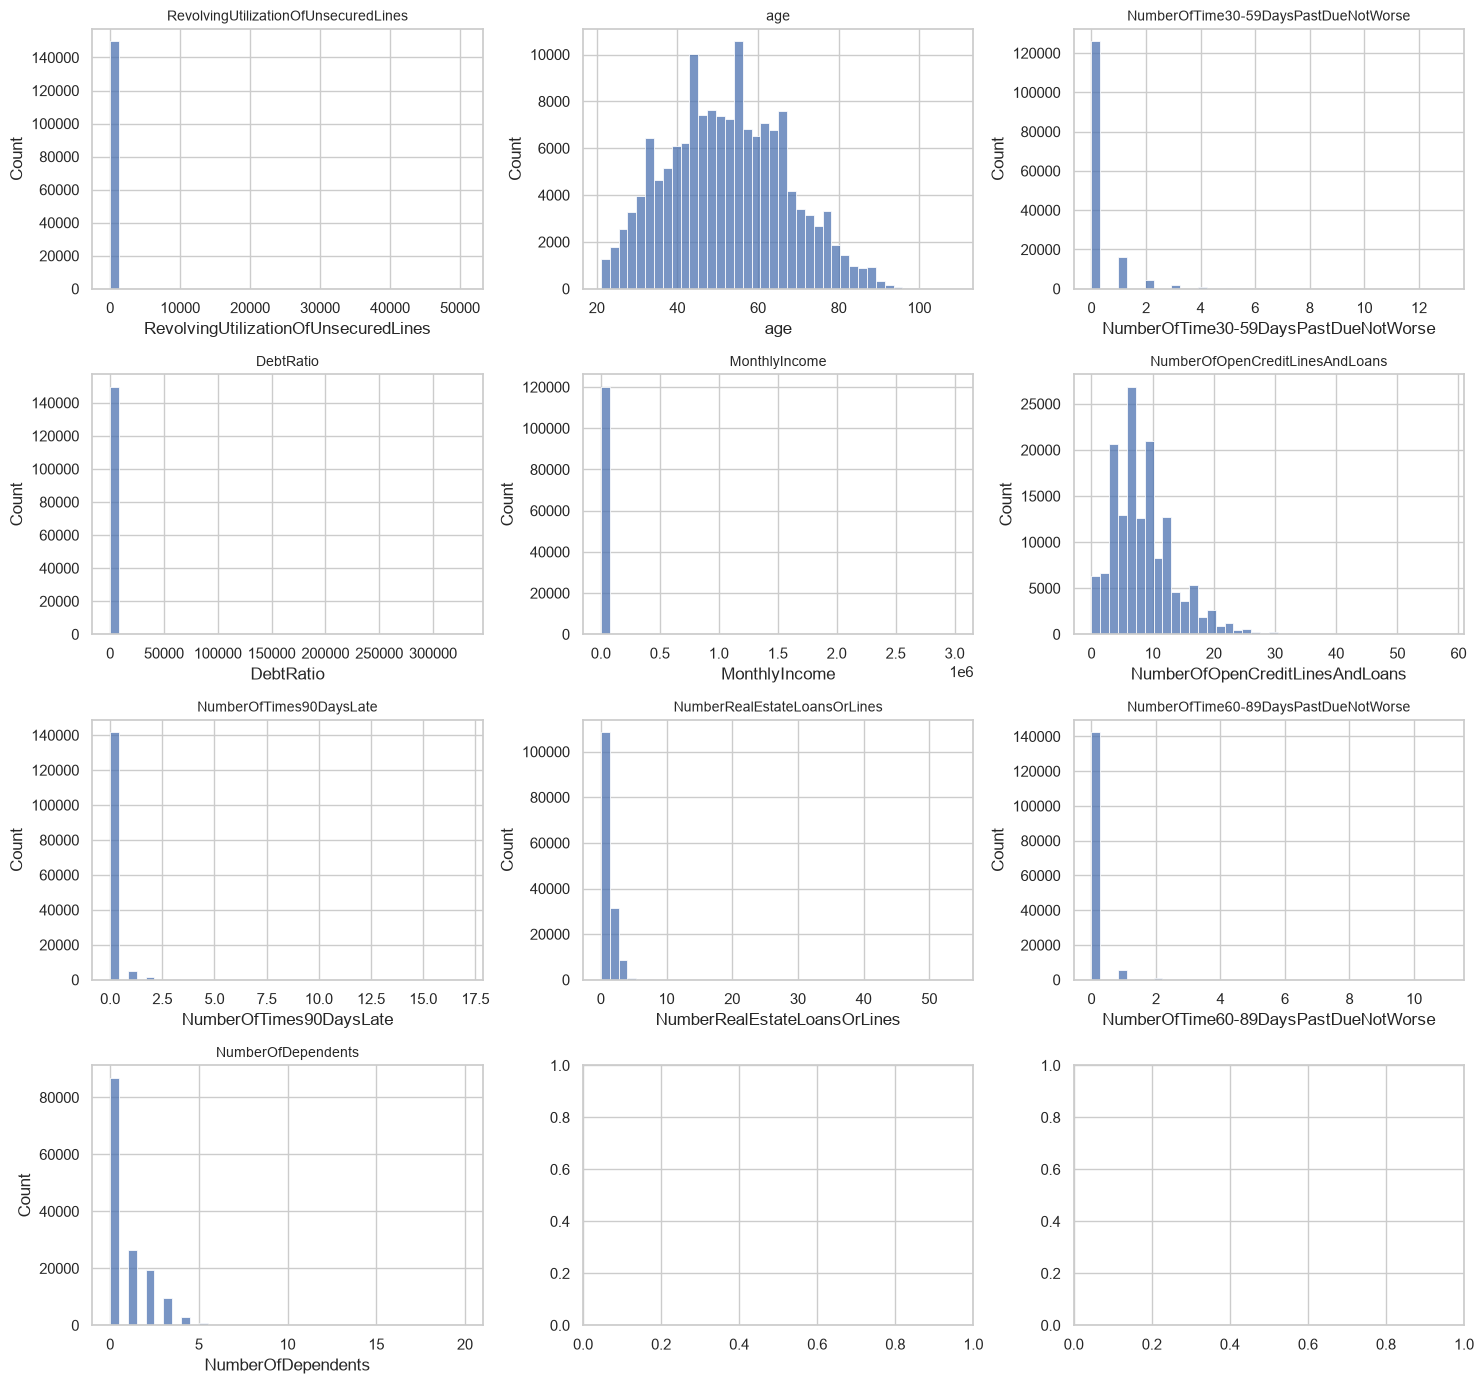

In [9]:
num_cols = [c for c in df.columns if c != "SeriousDlqin2yrs"]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()


## Outliers em variaveis-chave

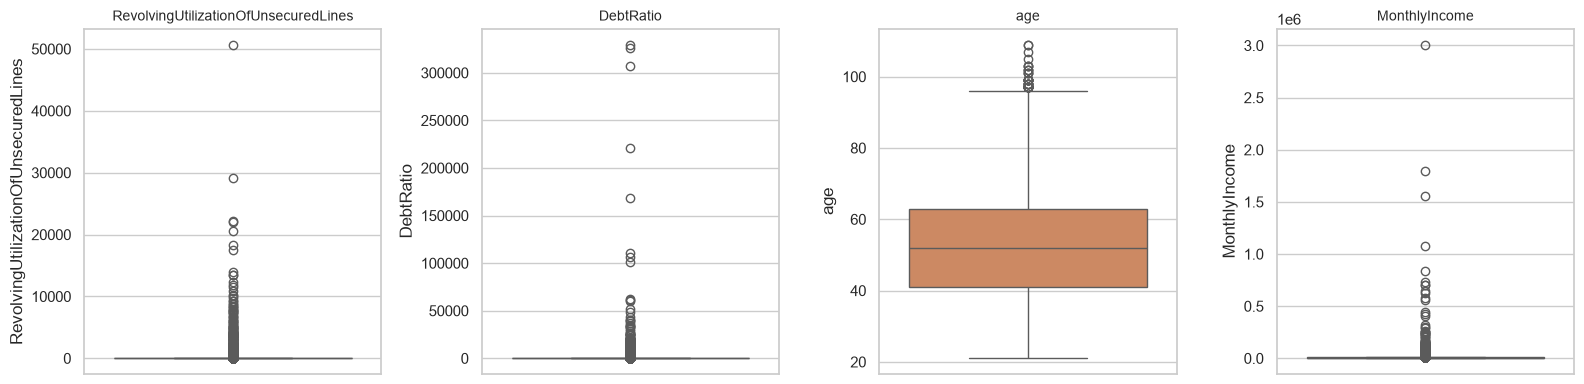

In [10]:
key_vars = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "age", "MonthlyIncome"]

fig, axes = plt.subplots(1, len(key_vars), figsize=(16, 4))
for ax, col in zip(axes, key_vars):
    sns.boxplot(y=df[col].dropna(), ax=ax, color="#DD8452")
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()


**Nota:** `RevolvingUtilizationOfUnsecuredLines` e `DebtRatio` apresentam outliers extremos (valores muito acima de 1, que nao fazem sentido para uma taxa de utilizacao). Estrategia de tratamento (cap por percentil ou remocao) sera decidida na proxima etapa.

## Correlacao entre variaveis

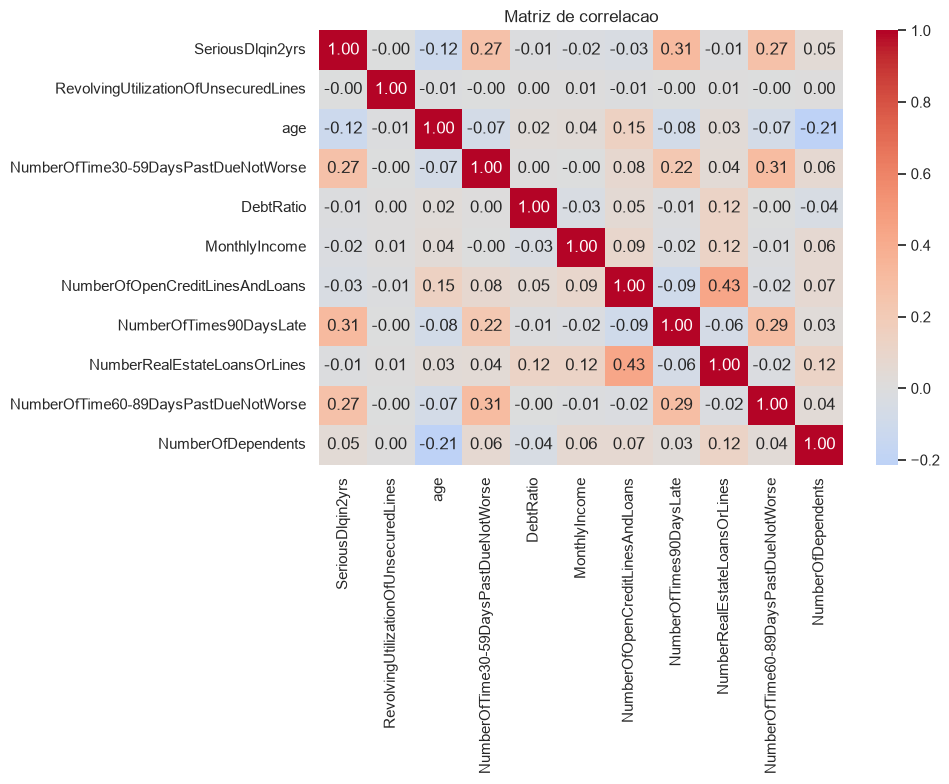

In [11]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlacao")
plt.tight_layout()
plt.show()


## Conclusoes da EDA

- Classe alvo desbalanceada (~6-7% de inadimplentes) -> exige balanceamento (SMOTE) na modelagem.
- `MonthlyIncome` e `NumberOfDependents` precisam de estrategia de imputacao (~20% e ~2,5% de ausentes, respectivamente).
- `RevolvingUtilizationOfUnsecuredLines` e `DebtRatio` tem outliers extremos que precisam de tratamento (cap por percentil) antes da modelagem.
- Os tres campos de atraso (`NumberOfTime...PastDue...`) sao os que mais correlacionam com a inadimplencia, como esperado.
- Proximo passo: `02_feature_engineering.ipynb`.